In [1]:
import geopandas as gpd
import pandas as pd
import sys

sys.path.insert(0, "../Modules")

from preprocessing_utils import *

pd.set_option('display.max_columns', None)

enc = 'utf-8'
dec = 'greek8'

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"


greece_gdf = gpd.read_file(f"{folder_path}/elladitsa.shp",  encoding=enc)
greece_regions_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [3]:
greece_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [4]:
greece_regions_gdf.head(5)

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [5]:
rivers_gdf.head(5)

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,basin_cd,status_yr,modified,artificial,alt_cat,geol_cat,size_cat,ms_cd,geology,lat,lon,size_,energy,av_width,av_depth,av_slope,riv_morph,discharge,val_morph,solids,acid_neut,substratum,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry
0,1,None,ÑÅÌÁ ÍÉÊÇÔÙÍ,REMA NIKHTVN,None,None,None,None,None,None,12,None,None,None,None,None,None,None,None,0.0,0.0,0.0,None,0.0,0.0,0.0,None,None,None,None,None,None,None,None,0.0,0.0,0.0,no,3035.444622,"LINESTRING (25.74206 41.10802, 25.74160 41.107..."
1,2,GR0012000400300270N,ÐËÁÔÕÑÅÌÌÁ Ñ.,PLATYRREMA S.,None,None,None,None,None,None,12,None,None,None,None,None,None,0012000400300270N,None,0.0,0.0,0.0,None,0.0,0.0,0.0,None,None,None,None,None,None,None,None,0.0,0.0,0.0,no,17558.809512,"LINESTRING (25.75701 41.20519, 25.75759 41.204..."
2,3,GR0004000400260520N,ÔÁÕÑÙÐÏÓ Ð.,TAVROPOS R.,None,None,None,None,None,None,04,None,None,None,None,None,None,0004000400260520N,None,0.0,0.0,0.0,None,0.0,0.0,0.0,None,None,None,None,None,None,None,None,0.0,0.0,0.0,no,42710.979405,"LINESTRING (21.76727 39.18674, 21.76728 39.186..."
3,4,None,ÌÁÕÑÏÑÑÅÌÁ,MAYRORREMA,None,None,None,None,None,None,12,None,None,None,None,None,None,None,None,0.0,0.0,0.0,None,0.0,0.0,0.0,None,None,None,None,None,None,None,None,0.0,0.0,0.0,no,6849.963018,"LINESTRING (26.26720 41.07231, 26.26821 41.071..."
4,5,GR0008000400220360N,ÅÍÉÐÅÕÓ Ð.,ENIPEYS R.,None,None,None,None,None,None,08,None,None,None,None,None,None,0008000400220360N,None,0.0,0.0,0.0,None,0.0,0.0,0.0,None,None,None,None,None,None,None,None,0.0,0.0,0.0,no,13274.085824,"LINESTRING (22.11585 39.49631, 22.11806 39.495..."


<AxesSubplot:>

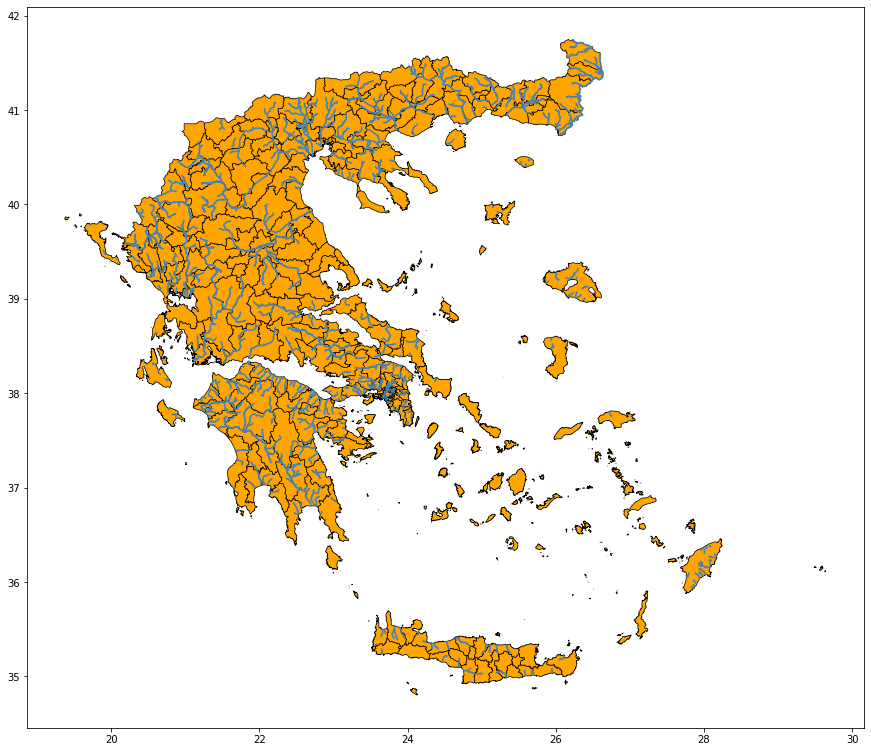

In [6]:
ax = rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='steelblue')
greece_gdf.plot(facecolor="none", edgecolor='black', ax=ax, color='orange', lw=0.7)

In [7]:
area = greece_gdf.copy()
area = area.to_crs({'init': 'epsg:3857'})
area['area'] = area['geometry'].area/ 10**6
area.rename(columns={"NAME": "lau1"}, inplace=True)
area.drop(columns=['KWD_YPES', 'geometry'], inplace=True)

process_greek(area, 'lau1')

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [8]:
area

,lau1,area
0,αμυνταιου,1027.268847
1,αθως,577.798463
2,ακτιου βονιτσας,1088.382897
3,ανδρου,613.262978
4,αργους μυκηνων,1599.506037
...,...,...
321,ψαρων,73.352048
322,ωραιοκαστρου,381.249371
323,ωρωπου,551.750676
324,κιμωλου,87.254457


In [9]:
lau1_processed = area['lau1'].drop_duplicates().sort_values().tolist()

with open('data/GR_SHP_lau1_processed.txt', 'w', encoding=enc) as f:
    for item in lau1_processed:
        f.write("%s\n" % item)

In [10]:
area.to_csv("data/GR_SHP_LAU1_area.csv", encoding = enc, index = False)